<div dir ="rtl">
    
## سوال ۱: اسکن  ۱۰ رکورد از دیتاست بانک نوشیروانی
<br><br>

</div>


In [1]:
import pandas as pd

file_name = "Bank NIT DB.csv"

# خواندن هزار تای اول
df = pd.read_csv(file_name , nrows = 1000 ,  encoding='utf-8-sig')


# انتخاب 10 تا به صورت رندوم از هزار تا اول
df_sample = df.sample(10, random_state=42)

df_sample



,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE
521,522,ابراهيم قلي زاده اله چالي,عليرضا,1353-01-01,بابل,مازندران,بابل,مازندران
737,738,پريسا انوري علي آباد,محمد,1352-07-12,NaN,NaN,تهران مرکزی,تهران
740,741,رضا پارسائي,احمدعلي,1357-03-22,بهبهان,خوزستان,اهواز,خوزستان
660,661,پروين صيفي,شاه كرم,1367-08-07,اسدآباد,همدان,اسدآباد,همدان
411,412,اميد ياري ديگه سرا,اردشير,1372-05-02,NaN,NaN,تهران مرکزی,تهران
678,679,علي بهرامي كوهشاهي,ابراهيم,1374-11-08,بافت,کرمان,NaN,NaN
626,627,سپيده نقيب زاده,ميرباقر,1365-06-08,NaN,NaN,ماکو,آذربایجان غربی
513,514,حميرا محمدي چناري,حشمت اله,1376-12-11,NaN,NaN,کرمانشاه,کرمانشاه
859,860,زينب كلاوند,فضلعلي,1357-12-03,NaN,NaN,تهران مرکزی,تهران
136,137,مرضيه كلانتري پور,محمود,1362-05-16,کرمان,کرمان,بردسیر,کرمان


<div dir ="rtl">
    
## سوال 2 پر کردن سطر های خالی در ستون محل سکونت
<br><br>


## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- شرط‌ها با regex بررسی می‌شوند:
  - خالی بودن: `^\s*$`
- اگر `PROVINCE_NAME` خالی و `BIRTH_PROVINCE` پر باشد، جایگزین می‌کند
- فایل اصلی را با نسخه اصلاح شده جایگزین می‌کند


</div>


In [ ]:
import pandas as pd
import re
import os
from IPython.display import display

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000


first_chunk = True

# یک میلیون یک میلیون می خونه در هر دور 
for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")


    # چک می کنه اگه استان سکونت نان یا استرینگ خالی بودش و استان تولد غیر نان و و غیر خالی بودش صحیح بر می گرداند
    mask = (  chunk['PROVINCE_NAME'].isnull() | 
            chunk['PROVINCE_NAME'].str.match(r'^\s*$', na=True))  & (chunk['BIRTH_PROVINCE'].notnull() &
              ~chunk['BIRTH_PROVINCE'].str.match(r'^\s*$', na=True) )
    chunk.loc[mask, 'PROVINCE_NAME'] = chunk['BIRTH_PROVINCE']
    
    # برای اینکه اگه بار اول بودش اسم فایل جدید بسازه یا اگه هم هست از اول بنویستش و در دفعه های بعد به متن اضافه کنه 
    if first_chunk:
        chunk.to_csv('Bank_NIT_Cleaned.csv', index=False, mode='w') # فایل رو از اول بنویسه
        first_chunk = False
    else:
        chunk.to_csv('Bank_NIT_Cleaned.csv', index=False, mode='a', header=False) # به فایل اضافه کنه 


df_show = pd.read_csv('Bank_NIT_Cleaned.csv', nrows=10)
print()
display(df_show)

# جایگزینی با فایل اصلاح شده
os.remove('Bank NIT DB.csv')
os.rename('Bank_NIT_Cleaned.csv', 'Bank NIT DB.csv')


Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...



,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE
0,1,افسانه جابريان,قاسم,1366-01-05,ايلام,ايلام,ایلام,ایلام
1,2,هادي حسن ونديان,حاجي علي,1357-10-06,NaN,مرکزی,اراک,مرکزی
2,3,فرح زعفري هشجين,حسين,1348-06-01,اسلامشهر,تهران,خلخال,اردبیل
3,4,قربانعلي نامجو,عباس,1335-06-17,شيراز,فارس,داراب,فارس
4,5,بهروز شاهبازي,نوروز,1360-06-30,تهران,تهران,ساری,مازندران
5,6,حميد احمدي قلعه قاضي,محمد,1365-10-10,بندرعباس,هرمزگان,بندرعباس,هرمزگان
6,7,قبادعلي خدري غريبوند,امام علي,1349-12-01,گناوه,بوشهر,کوهرنگ,چهارمحال و بختیاری
7,8,فتاح بيات بياتاني,ابوطالب,1336-02-01,NaN,تهران,تهران مرکزی,تهران
8,9,حميدرضا ايزدي يزدان آبادي,علي,1376-06-31,زرند,کرمان,زرند,کرمان
9,10,غلامرضا آقاجاني,صابر,1343-05-01,تبريز,اذربايجان شرقي,بوکان,آذربایجان غربی


<div dir ="rtl">
    
## سوال 3 درست کردن اندازه کد ملی ها 
<br>

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- با regex فقط اعداد را استخراج می‌کند: `\d+`
- با `zfill(10)` از چپ صفر می‌گذارد تا ۱۰ رقم شود
- اگر بیشتر از ۱۰ رقم باشد، ۱۰ رقم اول را نگه می‌دارد(البته کلا از 1 تا 32 میلیون هستتن و یعنی در بدترین حالت 10 رقمه و بیشتر نیست فقط محض احتیاط این را قرار دادم)
- فایل اصلی را با نسخه اصلاح شده جایگزین می‌کند


</div>


In [ ]:
import pandas as pd
import re
import os

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

pattern = re.compile(r'\d+') # عدد باشه فقط حالا به یه تعدادی حداقل یکی
first_chunk = True

for chunk_num, chunk in enumerate(
    pd.read_csv(file_path, chunksize=chunk_size, encoding="utf-8", encoding_errors="ignore", dtype=str),
    start=1
):

    print(f"Processing chunk {chunk_num}...")

    #  میاد اعداد هایی که هستن رو می گیره و بهش تا جایی که به 10 کارکتر برسه 0 اضافه می کنه و
    #  اخر هم اگه خود اون کد ملی از 10 رقم بیشتر بوده فقط 10 تای اول رو می گیره البته چون این تقریبا 32 میلون و اینا 
    # دیگه اوجش عدد 10 رقمی هست و بیشتر نیست فقط به دلیل احتیاط این شرط هم گذاشته شده
    chunk['national_code'] = chunk['national_code'].apply(
        lambda x: (''.join(pattern.findall(str(x)))).zfill(10)[:10]
    )
    
    # برای اینکه صفر های پشت عدد بمونن و معنی دار باشه به استرینگ تبدیلش می کنیم
    chunk['national_code'] = chunk['national_code'].astype(str)

    if first_chunk:
        chunk.to_csv('Bank_NIT_Cleaned.csv', index=False, mode='w')
        first_chunk = False
    else:
        chunk.to_csv('Bank_NIT_Cleaned.csv', index=False, mode='a', header=False)



os.remove('Bank NIT DB.csv')

os.rename('Bank_NIT_Cleaned.csv', 'Bank NIT DB.csv')


df = pd.read_csv('Bank NIT DB.csv', nrows=10, encoding="utf-8", dtype=str)
df




Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE
0,0000000001,افسانه جابريان,قاسم,1366-01-05,ايلام,ايلام,ایلام,ایلام
1,0000000002,هادي حسن ونديان,حاجي علي,1357-10-06,NaN,مرکزی,اراک,مرکزی
2,0000000003,فرح زعفري هشجين,حسين,1348-06-01,اسلامشهر,تهران,خلخال,اردبیل
3,0000000004,قربانعلي نامجو,عباس,1335-06-17,شيراز,فارس,داراب,فارس
4,0000000005,بهروز شاهبازي,نوروز,1360-06-30,تهران,تهران,ساری,مازندران
5,0000000006,حميد احمدي قلعه قاضي,محمد,1365-10-10,بندرعباس,هرمزگان,بندرعباس,هرمزگان
6,0000000007,قبادعلي خدري غريبوند,امام علي,1349-12-01,گناوه,بوشهر,کوهرنگ,چهارمحال و بختیاری
7,0000000008,فتاح بيات بياتاني,ابوطالب,1336-02-01,NaN,تهران,تهران مرکزی,تهران
8,0000000009,حميدرضا ايزدي يزدان آبادي,علي,1376-06-31,زرند,کرمان,زرند,کرمان
9,0000000010,غلامرضا آقاجاني,صابر,1343-05-01,تبريز,اذربايجان شرقي,بوکان,آذربایجان غربی


<div dir ="rtl">
    
## سوال 4 کشف اختلاس 
<br><br>

# فیلتر علیزاده‌های هرمزگان

ردیف‌هایی که نام خانوادگی "علیزاده" و استان سکونت "هرمزگان" دارند را پیدا می‌کند.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- ردیف‌های با نام یا استان خالی را حذف می‌کند
- regex های استفاده شده:
  - نام خانوادگی: `.*عليزاده$`
  - استان: `^\s*هرمزگان\s*$`
- نتیجه نهایی را نمایش می‌دهد


</div>


In [ ]:
import pandas as pd
import re
from IPython.display import display

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

# اونایی که اسم کاملشون با عیلزاده تموم میشه 
pattern = re.compile(r".*عليزاده$")
pattern2 = re.compile(r"^\s*هرمزگان\s*$")
#ي


results = []

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")

    # حذف ردیف‌هایی که FULL_NAME یا PROVINCE_NAME خالی هستن
    chunk = chunk.dropna(subset=["FULL_NAME", "PROVINCE_NAME"])

    # پاک کردن فضای خالی از FULL_NAME
    chunk["FULL_NAME"] = chunk["FULL_NAME"].str.strip()
    chunk["PROVINCE_NAME"] = chunk["PROVINCE_NAME"].str.strip()

    # Regex: نام خانوادگی با "علیزاده" شروع بشه
    mask_name = chunk["FULL_NAME"].apply(lambda x: bool(pattern.search(x)))

    # Regex: استان سکونت دقیقاً "هرمزگان" باشه
    mask_province = chunk["PROVINCE_NAME"].apply(
        lambda x: bool(pattern2.search(x))
    )

    # ترکیب دو شرط
    mask = mask_name & mask_province

    result = chunk.loc[mask].copy()

    if not result.empty:
        results.append(result)

# نمایش نتیجه
if results:
    final_result = pd.concat(results, ignore_index=True)
    print(f"\n{len(final_result)}")
    display(final_result)
else:
    print("\nno result")

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...

✅ تعداد افراد پیدا شده: 327


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE
0,27291,سعيد عليزاده,فريدون,1363-06-29,بندرعباس,هرمزگان,بندرعباس,هرمزگان
1,36467,اميرعباس عليزاده,علي,1385-10-14,بندرعباس,هرمزگان,بندرعباس,هرمزگان
2,115490,كبري حاجي عليزاده,مريد,1358-01-01,ميناب,هرمزگان,شهربابک,کرمان
3,130116,معراج عليزاده,اسلام,1384-02-01,ميناب,هرمزگان,میناب,هرمزگان
4,455097,مصطفي عليزاده,محمود,1367-06-30,بندرعباس,هرمزگان,بندرعباس,هرمزگان
...,...,...,...,...,...,...,...,...
322,31653787,حامد عليزاده,كريم,1374-08-30,بندرعباس,هرمزگان,بندرعباس,هرمزگان
323,31733943,ريحانه عليزاده,سيروس,1378-04-22,کيش,هرمزگان,کازرون,فارس
324,31804227,پروين عليزاده,جانعلي,1362-09-06,بندرعباس,هرمزگان,میاندوآب,آذربایجان غربی
325,31804698,الناز عليزاده,فريدون,1368-12-27,بندرعباس,هرمزگان,بندرعباس,هرمزگان


<div dir ="rtl">
    
## سوال 5 اضافه کرد ستون ADDRESS
<br><br>

# افزودن آدرس خوابگاه امینیان

به حسن‌پورهای ساکن اصفهان، آدرس "خوابگاه امینیان" را اضافه می‌کند.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- ستون `ADDRESS` را ایجاد می‌کند
- regex های استفاده شده:
  - نام خانوادگی: `.*حسنپور$`
  - استان: `^\s*اصفهان\s*$`
- برای رکوردهای منطبق، آدرس را پر و نتیجه را نمایش می‌دهد
- فایل اصلی را با نسخه به‌روزرسانی شده جایگزین می‌کند


</div>


In [ ]:
import pandas as pd
import re
import os

file_path = "Bank NIT DB.csv" 
chunk_size = 1_000_000

pattern = re.compile(r".*حسنپور$")
pattern2 = re.compile(r"^\s*اصفهان\s*$")

first_chunk = True
results = []

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")

    # پاک کردن فضای خالی 
    chunk["FULL_NAME"] = chunk["FULL_NAME"].str.strip()
    chunk["PROVINCE_NAME"] = chunk["PROVINCE_NAME"].str.strip()
    
    # اضافه کردن ستون ADDRESS
    chunk["ADDRESS"] = ""
    
    # ایجاد ماسک برای شرایط (با مدیریت NaN)
    mask_name = chunk["FULL_NAME"].fillna('').apply(lambda x: bool(pattern.search(x)))
    mask_province = chunk["PROVINCE_NAME"].fillna('').apply(lambda x: bool(pattern2.search(x)))
    
    mask = mask_name & mask_province
    # اگه شرایط رو داشتن بیاد ادرس رو خوابگاه امینیان بزاره
    chunk.loc[mask, "ADDRESS"] = "خوابگاه امینیان"
    
    # ذخیره رکوردهای منطبق برای نمایش
    result = chunk.loc[mask].copy()
    if not result.empty:
        results.append(result)
    
    # نوشتن در فایل موقت
    if first_chunk:
        chunk.to_csv('Bank_NIT_Cleaned.csv', index=False, mode='w', encoding='utf-8-sig')
        first_chunk = False
    else:
        chunk.to_csv('Bank_NIT_Cleaned.csv', index=False, mode='a', header=False, encoding='utf-8-sig')

# نمایش نتایج
if results:
    final_result = pd.concat(results, ignore_index=True)
    print(f"\n {len(final_result)}")
    display(final_result)
else:
    print("\nno result")

# جایگزینی فایل اصلی با فایل جدید
os.remove('Bank NIT DB.csv')
os.rename('Bank_NIT_Cleaned.csv', 'Bank NIT DB.csv')


df = pd.read_csv('Bank NIT DB.csv', nrows=5, encoding='utf-8-sig')
display(df)

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...

 11


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS
0,0001670940,قاسم حسنپور,خداكرم,1355-03-01,خميني شهر,اصفهان,اصفهان,اصفهان,خوابگاه امینیان
1,0003736588,پيمان حسنپور,قدرت اله,1367-06-30,NaN,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان
2,0005505963,پيمان حسنپور,قدرت اله,1367-06-30,NaN,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان
3,0009095146,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان
4,0011996700,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان
5,0018220279,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان
6,0019110095,پرديس حسنپور,محمد,1366-03-25,اصفهان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان
7,0019357028,آزاده حسنپور,علي,1368-02-30,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان
8,0022075214,قاسم حسنپور,خداكرم,1355-03-01,اصفهان,اصفهان,اصفهان,اصفهان,خوابگاه امینیان
9,0026864105,پوريا حسنپور,موسي,1378-11-27,اصفهان,اصفهان,اصفهان,اصفهان,خوابگاه امینیان


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS
0,1,افسانه جابريان,قاسم,1366-01-05,ايلام,ايلام,ایلام,ایلام,NaN
1,2,هادي حسن ونديان,حاجي علي,1357-10-06,NaN,مرکزی,اراک,مرکزی,NaN
2,3,فرح زعفري هشجين,حسين,1348-06-01,اسلامشهر,تهران,خلخال,اردبیل,NaN
3,4,قربانعلي نامجو,عباس,1335-06-17,شيراز,فارس,داراب,فارس,NaN
4,5,بهروز شاهبازي,نوروز,1360-06-30,تهران,تهران,ساری,مازندران,NaN


<div dir ="rtl">
    
## سوال 6 اضافه کردن شماره کارت
<br><br>

# تولید شماره کارت بانکی

برای هر رکورد یک شماره کارت ۱۶ رقمی با پیش‌شماره 3550 تولید می‌کند.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- شماره کارت با فرمت `3550` + شماره ردیف ۱۲ رقمی می‌سازد
- regex اعتبارسنجی: `^3550\d{12}$`
- فایل اصلی را با نسخه جدید جایگزین می‌کند

## شماره کارت‌ها
- **غیرتصادفی و ترتیبی** هستند
- `3550` پیش‌شماره ثابت + شماره ردیف ۱۲ رقمی
- مثال: `3550000000000001`, `3550000000000002`, ...



</div>


In [5]:
import pandas as pd
import re
from IPython.display import display
import os

file_path = "Bank NIT DB.csv"
chunk_size = 1000_000

# ریجکس برای اعتبارسنجی نهایی
CARD_num = re.compile(r'^3550\d{12}$')

first_chunk = True
row_num = 0

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
): 

    print(f"Processing chunk {chunk_num}...")
    # تولید شماره کارت
    card_numbers = []
    for _ in range(len(chunk)):
        row_num += 1
        # ساخت کارت با فرمت 3550 + 12 رقم
        card = f"3550{row_num:012d}"
        # اعتبارسنجی با ریجکس
        if CARD_num.match(card):
            card_numbers.append(card)
        else:
            card_numbers.append(None)
    
    chunk["CARD_NUMBERS"] = card_numbers
    
    # ذخیره
    if first_chunk:
        chunk.to_csv('Bank_NIT_Final.csv', index=False, mode='w')
        first_chunk = False
    else:
        chunk.to_csv('Bank_NIT_Final.csv', index=False, mode='a', header=False)
    


test_df = pd.read_csv('Bank_NIT_Final.csv', nrows=10, encoding="utf-8")
display(test_df)

os.remove('Bank NIT DB.csv')

os.rename('Bank_NIT_Final.csv', 'Bank NIT DB.csv')

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS
0,1,افسانه جابريان,قاسم,1366-01-05,ايلام,ايلام,ایلام,ایلام,NaN,3550000000000001
1,2,هادي حسن ونديان,حاجي علي,1357-10-06,NaN,مرکزی,اراک,مرکزی,NaN,3550000000000002
2,3,فرح زعفري هشجين,حسين,1348-06-01,اسلامشهر,تهران,خلخال,اردبیل,NaN,3550000000000003
3,4,قربانعلي نامجو,عباس,1335-06-17,شيراز,فارس,داراب,فارس,NaN,3550000000000004
4,5,بهروز شاهبازي,نوروز,1360-06-30,تهران,تهران,ساری,مازندران,NaN,3550000000000005
5,6,حميد احمدي قلعه قاضي,محمد,1365-10-10,بندرعباس,هرمزگان,بندرعباس,هرمزگان,NaN,3550000000000006
6,7,قبادعلي خدري غريبوند,امام علي,1349-12-01,گناوه,بوشهر,کوهرنگ,چهارمحال و بختیاری,NaN,3550000000000007
7,8,فتاح بيات بياتاني,ابوطالب,1336-02-01,NaN,تهران,تهران مرکزی,تهران,NaN,3550000000000008
8,9,حميدرضا ايزدي يزدان آبادي,علي,1376-06-31,زرند,کرمان,زرند,کرمان,NaN,3550000000000009
9,10,غلامرضا آقاجاني,صابر,1343-05-01,تبريز,اذربايجان شرقي,بوکان,آذربایجان غربی,NaN,3550000000000010


<div dir ="rtl">
    
## سوال  7 پس گرفتن پول دکتر
<br><br>

# جستجوی "حسینی مهدوی"

ردیف‌هایی که عبارت "حسینی مهدوی" در نام کامل آنها وجود دارد را پیدا می‌کند.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- فضای خالی ابتدا و انتهای نام‌ها را حذف می‌کند
- regex استفاده شده: `حسيني\s*مهدوي`
  - `\s*` یعنی هیچی یا یکی یا چند فاصله بین دو کلمه




</div>


In [ ]:
import pandas as pd
import re

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

#ي
pattern = re.compile(r"حسيني\s*مهدوي")

results = []

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # میاد فضا های خالی قبل و بعد اسم رو حذف می کنه
    chunk["FULL_NAME"] = chunk["FULL_NAME"].astype(str).str.strip()
    
    # جستجو با ریجکس
    mask = chunk["FULL_NAME"].apply(lambda x: bool(pattern.search(x)))
    
    #اونایی که ماسک براشون درست بودخ رو می ریزه تو result
    result = chunk[mask].copy()
    
    # جمع‌آوری دیتافریم‌های هر چانک در لیست
    if not result.empty:
        results.append(result)

if results:
    # چسباندن همه دیتافریم‌های لیست به هم
    final = pd.concat(results, ignore_index=True)
    display(final)
else:
    print("no result")

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS
0,0009548370,پژمان شاه حسيني مهدوي,حسين,1363-05-21,NaN,تهران,تهران مرکزی,تهران,NaN,3550000009548370
1,0022143734,حسن شاه حسيني مهدوي,باقر,1329-10-02,NaN,قزوین,بوئین زهرا,قزوین,NaN,3550000022143734
2,0022251901,سيدرمضان حسيني مهدوي,قنبر,1342-04-01,کلاله,گلستان,علی آباد,گلستان,NaN,3550000022251901


<div dir ="rtl">
    
## سوال 8 پیدا کردن وانیا ها 
<br><br>

# جستجوی نام‌های شروع‌شده با "وانیا"

ردیف‌هایی که نام کامل با "وانیا" شروع می‌شود را پیدا و تعدادشان را نمایش می‌دهد.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- فضای خالی ابتدا و انتهای نام‌ها را حذف می‌کند
- regex استفاده شده: `^وانيا`
  - `^` یعنی از ابتدای رشته شروع شود
- تعداد کل موارد یافت‌شده و خود رکوردها را نمایش می‌دهد


</div>


In [ ]:
import pandas as pd
import re

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

#ي
pattern = re.compile(r"^وانيا")

total_count = 0

results = []

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # به رشته تبدیل می کنه و فضای خالی ابتدا و انتها رو حذف می کنه
    chunk["FULL_NAME"] = chunk["FULL_NAME"].astype(str).str.strip()
    
    # جستجو با ریجکس
    mask = chunk["FULL_NAME"].apply(lambda x: bool(pattern.search(x)))
    
    result = chunk[mask].copy()
    #لگه نتیجه ای برای سرچ در این 1 میلیون تا بوده میره در مجوعه
    if not result.empty:
        results.append(result)
        total_count += len(result)

if results:
    # همه ی اعضای مجموعه رو بهم می چسبونه
    final = pd.concat(results, ignore_index=True)
    print(total_count)
    display(final)
else:
    print("no result")

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE
0,75368,وانيا رهنما,غلامرضا,1383-01-17,NaN,NaN,تهران غرب,تهران
1,84503,وانيا شيخي,سامرند,1388-03-25,مهاباد,اذربايجان غربي,ارومیه,آذربایجان غربی
2,130888,وانيا رمضاني اصل,سعيد,1386-02-12,اهواز,خوزستان,بهبهان,خوزستان
3,306828,وانيار قوردوئي ميلان,امير,1398-07-04,خوي,اذربايجان غربي,خوی,آذربایجان غربی
4,334283,وانيا سمعي,آريا,1385-02-06,گرگان,گلستان,گرگان,گلستان
...,...,...,...,...,...,...,...,...
421,31720392,وانيا متين زاده,علي اكبر,1393-06-26,NaN,NaN,شمیران,تهران
422,31736400,وانيا سيف زاده دنجي,سبزعلي,1374-10-25,قائم شهر,مازندران,قائمشهر,مازندران
423,31746241,وانيا رسول آبادي,رضا,1385-02-15,علي آباد کتول,گلستان,رامیان,گلستان
424,31753196,وانيا شاه محمدي,احمد,1389-02-22,لنجان - زرين شهر,اصفهان,اصفهان,اصفهان


<div dir ="rtl">
    
## سوال 9 میانگین سنی
<br><br>

# مقایسه سنی متولدین ۱۲۹۰ و ۱۳۹۰

میانگین سن متولدین دهه ۱۲۹۰ و ۱۳۹۰ را محاسبه و در نمودار مقایسه می‌کند.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- regex های استفاده شده:
  - متولدین 1290-1299: `^129[0-9]`
  - متولدین 1390-1399: `^139[0-9]`
- میانگین سن بر اساس سال 1405 محاسبه می‌شود
- اختلاف سنی در نمودار میل‌ای نمایش داده می‌شود

## نیازمندی‌ها
- pandas
- matplotlib

</div>


Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...


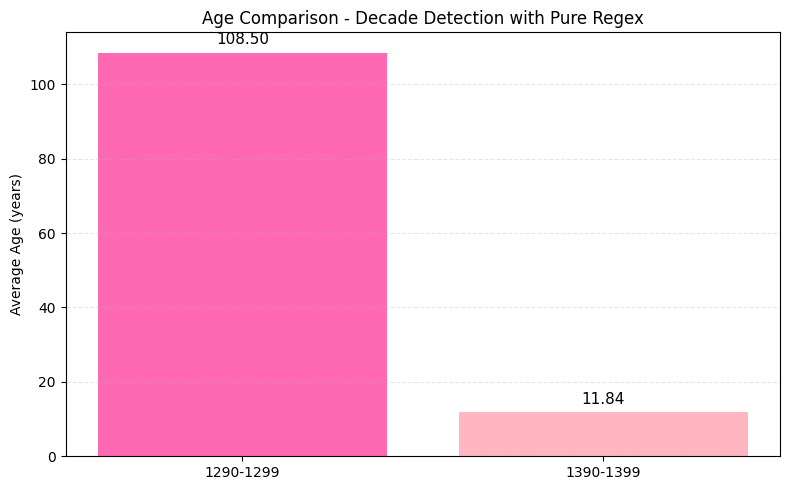


Born 1290-1299: 1,149 people

Born 1390-1399: 437,702 people



In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

sum_age_old = 0
count_old = 0
sum_age_new = 0
count_new = 0

current_year = 1405

# رجکس برای تشخیص دهه 1290-1299 و دهه 1390-1399
pattern_old = re.compile(r'^129[0-9]')  # 1290 تا 1299
pattern_new = re.compile(r'^139[0-9]')  # 1390 تا 1399
year_extract = re.compile(r'^(\d{4})')

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # اگه نان باشه به جاش استرینگ خالی می زاره و در کا تبدیل به استرینگ هم می کنه
    birth_dates = chunk["BIRTH_DATE"].fillna('').astype(str)
    
    for date_str in birth_dates:
        # چک کردن دهه با رجکس
        if pattern_old.match(date_str):
            # استخراج سال کامل برای محاسبه سن
            year_match = year_extract.match(date_str)
            if year_match:
                #چون year_match یه Match Object هست برای اینکه رشته 
                #ببرگردونه که بتونیم عددش کنیم از group استفاده کردیم
                year = int(year_match.group(1))
                count_old += 1 # یکی به تعداد اضافه کنه برای رده سنی
                sum_age_old += (current_year - year) #  سن طرف رو حساب کنه و جمع کنه با بقیه
                
        elif pattern_new.match(date_str):
            year_match = year_extract.match(date_str)
            if year_match:
                year = int(year_match.group(1))
                count_new += 1
                sum_age_new += (current_year - year)


# گرفتن میانگین با تقسیم جمع کل بر تعداد هر کدوم
avg_age_old = sum_age_old / count_old 
avg_age_new = sum_age_new / count_new 


# رسم نمودار
fig, ax = plt.subplots(figsize=(8, 5))

# هر میله چی زیرش نوشته باشه و چه رنگی باشن و چه اطلاعاتی داشته باشن
bars = ax.bar(['1290-1299', '1390-1399'], 
              [avg_age_old, avg_age_new],
              color=['#FF69B4', '#FFB6C1'])


for bar in bars:
     # گرفتن ارتفاع میله (مقدار داده)
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(avg_age_old, avg_age_new)*0.02),
            f'{height:.2f}', ha='center', fontsize=11)


# برچسب محور عمودی
ax.set_ylabel('Average Age (years)')

# عنوان نمودار
ax.set_title('Age Comparison - Decade Detection with Pure Regex')

# خطوط شبکه افقی با خط‌چین و شفافیت ۳۰٪
ax.grid(axis='y', linestyle='--', alpha=0.3)

# تنظیم خودکار فاصله‌ها و حاشیه‌ها
plt.tight_layout()

plt.show()

print()
print(f"Born 1290-1299: {count_old:,} people")
print(f"\nBorn 1390-1399: {count_new:,} people")
print()


<div dir ="rtl">
    
## سوال 10 پیدا کردن همزاد برای خودمان
<br><br>

# جستجوی تاریخ تولد دقیق

افرادی که دقیقاً در تاریخ ۱۳۸۵-۰۱-۰۶ متولد شده‌اند را پیدا می‌کند.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- regex استفاده شده: `^1385-01-06$`
  - `^` یعنی از ابتدای رشته
  - `$` یعنی تا انتهای رشته
  - فقط رکوردهایی که دقیقاً همین تاریخ باشند را می‌گیرد
- نتیجه نهایی را نمایش می‌دهد



</div>


In [ ]:
import pandas as pd
import re

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

# ساخت الگوی ریجکس برای پیدا کردن دقیقاً همین تاریخ
# ^ معنی شروع رشته، $ معنی پایان رشته
pattern = re.compile(r'^1385-01-06$')

found_records = []
total_rows = 0

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # حذف سطرهای بدون تاریخ تولد و جستجو با ریجکس
    mask = chunk["BIRTH_DATE"].fillna('').apply(
        lambda x: bool(pattern.match(str(x)))
    )
    
    result = chunk.loc[mask].copy()
    
    if not result.empty:
        found_records.append(result)

# جمع‌بندی نهایی
print("\n\n")
if found_records:
    all_matches = pd.concat(found_records, ignore_index=True)
    print(len(all_matches))
    display(all_matches)
    
else:
    print("no result")

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...



 443 


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,شماره کارت
0,0000102368,عسل حمزه نژاد,احمد,1385-01-06,بابل,مازندران,بابل,مازندران,NaN,3550000000102368
1,0000242243,اميررضا جوادزاده,سعيد,1385-01-06,اردبيل,اردبيل,اردبیل,اردبیل,NaN,3550000000242243
2,0000315265,فاطمه آباديان,محمد,1385-01-06,رفسنجان,کرمان,رفسنجان,کرمان,NaN,3550000000315265
3,0000378300,روژان حشمتي داياري,علي اكبر,1385-01-06,کرمانشاه,کرمانشاه,کرمانشاه,کرمانشاه,NaN,3550000000378300
4,0000385859,عسل مرادي دهبري,نظام,1385-01-06,شوش - هفت تپه,خوزستان,شوش,خوزستان,NaN,3550000000385859
...,...,...,...,...,...,...,...,...,...,...
438,0031823354,سجاد سعيدي,عبدالحسين,1385-01-06,يزد,يزد,اهواز,خوزستان,NaN,3550000031823354
439,0031862872,نگار گل پسند,رضا,1385-01-06,NaN,خراسان شمالی,بجنورد,خراسان شمالی,NaN,3550000031862872
440,0031975684,عبدالله اميري,مجيد,1385-01-06,شادگان,خوزستان,شادگان,خوزستان,NaN,3550000031975684
441,0032082388,رضا فتحي گرده سنگ,حسين,1385-01-06,تبريز,اذربايجان شرقي,تبریز,آذربایجان شرقی,NaN,3550000032082388


<div dir ="rtl">
    
## سوال 11 پدرانی با اسم های سخت برای عرب ها
<br><br>

# جستجوی حروف فارسی در نام پدر

ردیف‌هایی که نام پدرشان حاوی حروف خاص فارسی (گ، چ، پ، ژ) است را پیدا می‌کند.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- regex استفاده شده: `[گچپژ]`
  - `[...]` یعنی یکی از این کاراکترها وجود داشته باشد
- مقادیر خالی با `fillna('')` مدیریت می‌شوند
- تعداد و نتیجه نهایی نمایش داده می‌شود


</div>


In [ ]:
import pandas as pd
import re

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

# حروف غیرعربی (فارسی خاص)
pattern = re.compile(r'[گچپژ]')

found_records = []
count_total = 0

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # حذف مقادیر خالی و جستجو با ریجکس
    mask = chunk["FATHER_NAME"].fillna('').apply(
        lambda x: bool(pattern.search(str(x)))
    )
    
    result = chunk.loc[mask].copy()
    
    if not result.empty:
        found_records.append(result)
        count_total += len(result)

if found_records:
    all_matches = pd.concat(found_records, ignore_index=True)
    print(len(all_matches))
    display(all_matches)
    
else:
    print("\nNo records found with non-Arabic letters in FATHER_NAME!")

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...

713918


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,شماره کارت
0,0000000020,زهرا صالحي ريحاني,قپاني,1363-06-19,مسجدسليمان,خوزستان,ایذه,خوزستان,NaN,3550000000000020
1,0000000037,محمود اعتقادي,هوشنگ,1370-08-18,ايلام,ايلام,ایلام,ایلام,NaN,3550000000000037
2,0000000060,عليرضا سعيدي,بيگ محمد,1347-01-01,کرج,البرز,تبریز,آذربایجان شرقی,NaN,3550000000000060
3,0000000095,اشكان عزيزي,سپهدار,1371-09-23,شيراز,فارس,شیراز,فارس,NaN,3550000000000095
4,0000000192,ندا سليمان زاده,اسگندر,1358-09-03,گيوي,اردبيل,سنجبد(کوثر),اردبیل,NaN,3550000000000192
...,...,...,...,...,...,...,...,...,...,...
713913,0032105637,خدابخش كاوياني,جهانگير,1357-06-15,گچساران - دوگنبدان,کهکيلويه وبويراحمد,گچساران(دوگنبدان),کهکیلویه و بویراحمد,NaN,3550000032105637
713914,0032105649,اسماعيل خالدي برهنه,گردعلي,1377-12-03,لردگان,چهار محال بختياري,بویراحمد(یاسوج),کهکیلویه و بویراحمد,NaN,3550000032105649
713915,0032105832,بهروز صادقي فر,پيري,1361-06-30,خرم آباد,لرستان,خرم آباد,لرستان,NaN,3550000032105832
713916,0032105853,مهدي علميه,علي عسگر,1366-06-26,NaN,تهران,تهران مرکزی,تهران,NaN,3550000032105853


<div dir ="rtl">
    
## سوال 12 خلخالی ها
<br><br>

# جستجوی ساکنان خلخال در استان اردبیل

ردیف‌هایی که شهرشان "خلخال" و استانشان "اردبیل" است را پیدا می‌کند.

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) می‌خواند
- فاصله‌های اضافی ابتدا و انتها حذف می‌شوند
- regex های استفاده شده:
  - شهر: `^\s*خلخال\s*$` با پرچم `IGNORECASE`
  - استان: `^\s*اردبيل\s*$` با پرچم `IGNORECASE`
- `IGNORECASE` یعنی حساس به حروف بزرگ و کوچک نیست
- ترکیب دو شرط با `&` (هر دو باید برقرار باشند)
- تعداد کل و نتیجه نمایش داده می‌شود


</div>


In [2]:
import pandas as pd
import re

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

# الگوی ریجکس برای پیدا کردن خلخال در استان اردبیل
# (حساس به فاصله و حروف بزرگ/کوچک نیست)
pattern_city = re.compile(r'^\s*خلخال\s*$', re.IGNORECASE)
pattern_province = re.compile(r'^\s*اردبيل\s*$', re.IGNORECASE)

total_count = 0
found_records = []


for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # پاک کردن فاصله‌های اضافی
    chunk["CITY_NAME"] = chunk["CITY_NAME"].fillna('').astype(str).str.strip()
    chunk["PROVINCE_NAME"] = chunk["PROVINCE_NAME"].fillna('').astype(str).str.strip()
    
    # ماسک برای شهر خلخال و استان اردبیل
    mask_city = chunk["CITY_NAME"].apply(lambda x: bool(pattern_city.search(x)))
    mask_province = chunk["PROVINCE_NAME"].apply(lambda x: bool(pattern_province.search(x)))
    
    # ترکیب دو شرط
    mask = mask_city & mask_province
    
    count_in_chunk = mask.sum()
    total_count += count_in_chunk
    
    if count_in_chunk > 0:
        result = chunk.loc[mask].copy()
        found_records.append(result)
        

# نمایش نمونه
if found_records:
    all_matches = pd.concat(found_records, ignore_index=True)
    print(f"\n {total_count:,}")
    display(all_matches)
    
else:
    print("\nNo result")

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...

 28,903


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS
0,0000000959,اميرحسين شهبازي,علي رضا,1387-01-15,خلخال,اردبيل,خورش رستم,اردبیل,NaN,3550000000000959
1,0000001204,نگين كلانتري,علي,1374-04-17,خلخال,اردبيل,خلخال,اردبیل,NaN,3550000000001204
2,0000001566,شهين برزگردشتمياني,محمدقلي,1358-01-01,خلخال,اردبيل,رضوانشهر,گیلان,NaN,3550000000001566
3,0000002069,علي رضاپور,مرتضي,1353-05-19,خلخال,اردبيل,خلخال,اردبیل,NaN,3550000000002069
4,0000009365,سيداحمد رضازاده,سيدهوشنگ,1360-04-20,خلخال,اردبيل,خلخال,اردبیل,NaN,3550000000009365
...,...,...,...,...,...,...,...,...,...,...
28898,0032100614,سميه مولائي هشجين,توكل,1361-10-17,خلخال,اردبيل,خلخال,اردبیل,NaN,3550000032100614
28899,0032102016,هاجر طالب پور,نريمان,1361-10-04,خلخال,اردبيل,خلخال,اردبیل,NaN,3550000032102016
28900,0032104784,حسن نظري بفراجرد,جمشيد,1365-12-14,خلخال,اردبيل,خلخال,اردبیل,NaN,3550000032104784
28901,0032105422,سيدكيومرث نصيري,سيدفرامرز,1354-10-10,خلخال,اردبيل,خلخال,اردبیل,NaN,3550000032105422


<div dir="rtl">

## سوال 13 - فامیلی‌های اصیل

### شرح DFA
این DFA نام خانوادگی را از **آخر به اول** می‌خواند و بررسی می‌کند که به "ی" یا "پور" ختم شده باشد.

### حالات (States)
- **State 0 :** حالت شروع، منتظر اولین کاراکتر از آخر
- **State 1 :** حالت پذیرش، الگو پیدا شده
- **State 2 :** کاراکتر 'ر' دیده شده، در حال بررسی 'پور'
- **State 3 :** 'رو' دیده شده، منتظر 'پ'
- **State -1:** حالت رد، رشته نامعتبر

### مسیرهای انتقال
- **State 0:** اگر 'ی' بیاید ← State 1 (قبول) | اگر 'ر' بیاید ← State 2 | بقیه ← رد
- **State 2:** اگر 'و' بیاید ← State 3 | بقیه ← رد
- **State 3:** اگر 'پ' بیاید ← State 1 (قبول) | بقیه ← رد
- **State 1:** قبول نهایی، مهم نیست قبلش چی بوده
- **State -1:** رد نهایی، مهم نیست قبلش چی بوده


</div>

In [ ]:
def state0(c):
    if c == 'ي':
        return 1  # قبول
    elif c == 'ر':
        return 2  # شاید 'پور' باشه
    else:
        return -1  # رد

def state2(c):
    if c == 'و':
        return 3
    else:
        return -1

def state3(c):
    if c == 'پ':
        return 1  # قبول
    else:
        return -1

def is_accepted(family_name):
    if not family_name:
        return False
    
    # از آخر به اول میخونیم
    state = 0
    for char in reversed(family_name):
        if state == 0:
            state = state0(char)
        elif state == 1:
            return True
        elif state == 2:
            state = state2(char)
        elif state == 3:
            state = state3(char)
        elif state == -1:
            return False
    return state == 1

import pandas as pd
import os

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

non_standard_count = 0 
standard_count = 0 

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")

    # حذف  فضا های خالی
    family_names = chunk["FULL_NAME"].fillna('').astype(str).str.strip()
    # اعمال تابع روی همه شون
    family_names = family_names.apply(
        lambda x: x.split()[-1] if x and len(x.split()) > 0 else ""
    )


    # آمارگیری
    for family_name in family_names:
        if family_name:
            if is_accepted(family_name):
                standard_count += 1
            else:
                non_standard_count += 1


print()
print("FINAL RESULTS")
print(f"non_standard_count : {non_standard_count:,}")
print(f"standard_count : {standard_count:,}")
print()




Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...

FINAL RESULTS
non_standard_count : 12,090,618
standard_count : 20,015,337



<div dir ="rtl">
    
## سوال 14 پذیرش وام
<br><br>

# NFA تشخیص فامیلی‌های خاص

## شرح
یک NFA ساده که فامیلی‌های "رضایی‌نژاد" و "محمدی‌پور" را قبول و فامیلی‌های "احمدی" با تاریخ تولد ۱۳۷۰ تا ۱۴۰۴ را رد می‌کند.

## حالات (States)
- **State 0 (Start):** بررسی فامیلی
- **ACCEPT:** فامیلی "رضایی‌نژاد" یا "محمدی‌پور" ← قبول نهایی
- **CHECK_BIRTH:** فامیلی "احمدی" ← برو تاریخ تولد را چک کن
- **REJECT:** فامیلی "احمدی" و تاریخ تولد ۱۳۷۰-۱۴۰۴ ← رد
- **UNKNOWN:** هیچ‌کدام از شرایط ← نادیده گرفته می‌شود

## مسیرهای انتقال
- **State 0:** اگر فامیلی "رضایی‌نژاد" یا "محمدی‌پور" ← ACCEPT
- **State 0:** اگر فامیلی "احمدی" ← CHECK_BIRTH
- **State 0:** سایر فامیلی‌ها ← UNKNOWN (بی‌تأثیر)
- **CHECK_BIRTH:** اگر تاریخ تولد بین ۱۳۷۰ تا ۱۴۰۴ ← REJECT
- **CHECK_BIRTH:** سایر تاریخ‌ها ← UNKNOWN (بی‌تأثیر)

## regex های استفاده شده
- `.*رضايينژاد$` ← فامیلی "رضایی‌نژاد"
- `.*محمديپور$` ← فامیلی "محمدی‌پور"
- `احمدي$` ← فامیلی "احمدی"
- `^13[7-9][0-9]|140[0-4]` ← تاریخ تولد ۱۳۷۰ تا ۱۴۰۴

## نیازمندی
- pandas

</div>


In [ ]:
import pandas as pd
import re

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

def nfa_batch(full_names, birth_dates):
    # الگوهای ریجکس برای تطبیق فامیلی و تاریخ تولد
    pattern_powerful = re.compile(r".*رضايينژاد$")      
    pattern_powerful2 = re.compile(r".*محمديپور$")      
    pattern_ahmadi = re.compile(r'احمدي$')                
    pattern_birth = re.compile(r'^13[7-9][0-9]|140[0-4]') # تاریخ تولد 1370 تا 1404
    
    # State 0: بررسی فامیلی
    def state0(family):
        if pattern_powerful.search(family):     # اگر رضایی‌نژاد بود
            return 1
        if pattern_powerful2.search(family):    # اگر محمدی‌پور بود
            return 1
        elif pattern_ahmadi.search(family):     # اگر احمدی بود → برو تاریخ چک کن
            return 2
        else:
            return -1                    # هیچ‌کدام → نادیده بگیر
    
    # State CHECK_BIRTH: بررسی تاریخ تولد برای احمدی‌ها
    def state2(birth):
        if pattern_birth.match(birth[:4]) if birth and len(birth) >= 4 else False:
            return -2                      # تاریخ 1370-1404 → رد
        return -1                         # تاریخ خارج بازه → نادیده بگیر
    
    accept_in_chunk = 0   
    reject_in_chunk = 0   
    
    # استخراج فامیلی (آخرین کلمه نام کامل)
    names = full_names.fillna('').astype(str).str.strip().str.split().str[-1].tolist()
    births = birth_dates.fillna('').astype(str).tolist()
    
    
    for fam, bdt in zip(names, births):
        s0 = state0(fam)                    # مرحله اول: فامیلی چیه؟
        
        if s0 == 1:
            accept_in_chunk += 1            # قبول نهایی
        elif s0 == 2:
            if state2(bdt) == -2:     # مرحله دوم: تاریخ تولد چک بشه
                reject_in_chunk += 1        # رد شد
    
    return accept_in_chunk, reject_in_chunk

# شمارنده‌های کلی
total_accept = 0
total_reject = 0


for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # پردازش هر چانک
    accept_count, reject_count = nfa_batch(chunk["FULL_NAME"], chunk["BIRTH_DATE"])
    
    
    total_accept += accept_count
    total_reject += reject_count

# نمایش نتایج نهایی
print(f"ACCEPT (رضایینژاد or محمدیپور): {total_accept:,}")
print(f"REJECT (احمدی + born 1370-1404): {total_reject:,}")


Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
ACCEPT (رضایینژاد or محمدیپور): 0
REJECT (احمدی + born 1370-1404): 54,596


<div dir ="rtl">
    
## سوال 15 نام خانوادگی خاص
<br><br>
# DFA تشخیص فامیلی استاندارد

فامیلی‌هایی که به یکی از حروف "ز"، "ژ"، "و"، "ه" ختم شوند را استاندارد تشخیص می‌دهد.

## حالات (States)
- **State 0:** شروع - بررسی کاراکتر آخر
- **State 1:** کاراکتر آخر یکی از حروف "ز، ژ، و، ه" بوده
- **State 2:** قبول - بعد از حرف آخر، مصوت آمده (الگوی ۲ حرفی)
- **State -1:** رد

## مسیرهای انتقال
- **State 0:** اگر کاراکتر آخر "ز، ژ، و، ه" باشد ← State 1 | در غیر این صورت ← رد
- **State 1:** اگر کاراکتر قبلی مصوت ("ا، آ، و، ی" یا "ای، او") باشد ← State 2 (قبول)
- **State 1:** اگر مصوت نباشد ← همچنان State 1 (قبول)
- **State 2:** قبول نهایی

## regex های استفاده شده
- `[زژوه]` ← حروف "ز، ژ، و، ه"
- `[اآوي]|اي|او` ← مصوت‌ها: "ا، آ، و، ی" یا ترکیب "ای" و "او"

## نیازمندی
- pandas


</div>


In [14]:
import pandas as pd
import re

def state0(c):
    if re.match(r'[زژوه]', c): # اگر حرف آخر "ز، ژ، و، ه" بود
        return 1               # برو به State 1
    else:                     # اگه هر چی جز اونا بودش
        return -1             # در غیر این صورت رد

def state1(c):
    if re.match(r'[اآوي]|اي|او', c):   # اگر مصوت ("ا، آ، و، ی" یا "ای، او") بود
        return 2                        # برو به استیت 2 که پایانی هستش
    else:
        return 1                        # اگه هر چی جز  مصوت ها بودش تو هیمن استیت بمون

def is_accepted(family_name):
    if not family_name or len(family_name) < 2: # فامیلی خالی یا تک‌حرفی قبول نیست
        return False
    
    state = 0
    # خواندن از آخر به اول
    for char in reversed(family_name):
        if state == 0:
            state = state0(char)
        elif state == 1:
            state = state1(char)
        elif state == 2:
            return True
        elif state == -1:
            return False
    return state != 1

file_path = "Bank NIT DB.csv"
df = pd.read_csv(file_path, encoding="utf-8", encoding_errors="ignore", dtype=str, nrows=100)


# استخراج فامیلی (آخرین کلمه نام کامل)
family_names = df["FULL_NAME"].fillna('').astype(str).str.strip()
family_names = family_names.apply(lambda x: x.split()[-1] if x and len(x.split()) > 0 else "")

standard_count = 0
non_standard_count = 0

# بررسی تک‌تک فامیلی‌ها
for family_name in family_names:
    if family_name:
        if is_accepted(family_name):
            standard_count += 1
        else:
            non_standard_count += 1

print(f"standard_count : {standard_count}")
print(f"non_standard_count : {non_standard_count}")

standard_count : 6
non_standard_count : 94


<div dir="rtl">

## سوال 16 - تشخیص مشتری ریسک بالا با NFA
<br><br>

# NFA تشخیص مشتری ریسک بالا

مشتری در صورتی "ریسک بالا" محسوب می‌شود که **حداقل دو** شرط از سه شرط زیر برقرار باشد.

## شرایط
- **a:** فامیلی "اصغری" یا "جعفری" + سال تولد ۱۳۶۰ تا ۱۳۸۰
- **b:** استان سکونت: سیستان و بلوچستان، هرمزگان، یا خوزستان
- **c:** نام کوچک شامل حرف "ز" یا "ن"

## حالات (States)
- **State 0 (000):** شروع - هیچ شرطی برقرار نیست
- **State 1 (100):** فقط شرط a برقرار است
- **State 2 (010):** فقط شرط b برقرار است
- **State 3 (001):** فقط شرط c برقرار است
- **State 4 (110):** قبول - شرط a و b
- **State 5 (101):** قبول - شرط a و c
- **State 6 (011):** قبول - شرط b و c
- **State 7 (111):** قبول - هر سه شرط

## مسیرهای انتقال (موازی - ویژگی NFA)
- از State 0: سه مسیر همزمان به State 1 (شرط a)، State 2 (شرط b)، State 3 (شرط c)
- از State 1: مسیر به State 4 (اگر b) یا State 5 (اگر c)
- از State 2: مسیر به State 4 (اگر a) یا State 6 (اگر c)
- از State 3: مسیر به State 5 (اگر a) یا State 6 (اگر b)

## ویژگی NFA بودن
- سه شرط **همزمان و موازی** از State 0 بررسی می‌شوند
- NFA می‌تواند همزمان در چند State باشد (چند مسیره)
- با OR بیتی (`|=`) حالت‌ها ترکیب می‌شوند
- Accept States: حالت‌هایی که حداقل ۲ بیت ۱ دارند (011، 101، 110، 111)

## regex های استفاده شده
- `.*(اصغری|جعفری)$` ← شرط a - فامیلی
- `^(13[6-7][0-9]|1380)` ← شرط a - سال تولد
- `^\s*(سیستان و بلوچستان|هرمزگان|خوزستان)\s*$` ← شرط b
- `[زن]` ← شرط c



</div>


<div dir="rtl">
<br>
<br>

## چرا NFA به DFA تبدیل می‌شود اما تعداد حالات ممکن است زیاد شود؟

هر NFA طبق قضیه Rabin-Scott به DFA تبدیل می‌شود. دلیل اینکه ممکن است تعداد حالات زیاد شود این است که:

۱. در NFA ما از State 1 فقط با ورودی‌های b و c خروجی تعریف شده، اما با ورودی a خروجی‌ای مشخص نشده. همین‌طور از State 2 با a و c و از State 3 با a و b. این یعنی NFA برای بعضی ورودی‌ها **انتقال تعریف‌نشده** دارد.

۲. در DFA اما **هر State باید برای تمام ورودی‌ها** (a, b, c) یک مقصد مشخص داشته باشد. پس مجبوریم برای ورودی‌های تعریف‌نشده یک **Dead State** (حالت مرده) اضافه کنیم.
و در اصل اگه در استیت 1 a می تونه به خودش بره و این یه حلقه بی نهایت بشه یا اگه هم به استست رد بره باز امکان داره که یکی از شرط
دیگه رو هم می تونسته ببینه و رسما در این حالت برای a  دیدن جایی ندارد و مشکل ایجاد می شود
۳. اگر NFA واقعاً غیرقطعی بود (یک ورودی به چند State مختلف می‌رفت)، آنگاه با روش Subset Construction تعداد حالات DFA تا 2^n برابر NFA افزایش می‌یافت. در NFA ما ۵ حالت داریم، پس در بدترین حالت DFA می‌توانست تا 2⁵=32 حالت داشته باشد.

۴. اما چون NFA ما فقط انتقال تعریف‌نشده دارد (نه چندمسیره)، تبدیل به DFA تنها با افزودن یک Dead State انجام می‌شود و تعداد حالات از ۵ به ۶ می‌رسد که افزایش چشمگیری نیست.



</div>

In [ ]:
import pandas as pd
import re

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

# regex ها (همان regex های تو)
pattern_family = re.compile(r'.*(اصغری|جعفری)$')
pattern_birth = re.compile(r'^(13[6-7][0-9]|1380)')
pattern_province = re.compile(r'^\s*(سيستان\s*و\s*بلوچستان|هرمزگان|خوزستان)\s*$')
pattern_name = re.compile(r'[زن]')


def check_conditions(name, birth, province):
    """بررسی همزمان هر سه شرط - برگشت یک حالت ۳ بیتی"""
    
    # اسم فامیل رو از حاهایی که فاصله هستن جدا می کنه 
    parts = name.split() if name else []
    # اندیس اول که اسم کوچک هست رو ور می داره
    first_name = parts[0] if len(parts) > 0 else ""
    # چون امکان داره اسن چند بخشی یا فامیلی چند بخشی با فاصله باشه این برنامه میاد اخرین رو ور می داره 
    # اندیس اخر که فامیلی هست رو ور می داره
    family = parts[-1] if len(parts) > 0 else ""
    
    state = 0b000  # شروع از 000 استیت اول
    
    # State 0 → 1 (شرط a): فامیلی + سال تولد
    if pattern_family.search(family) and birth and len(birth) >= 4:
        if pattern_birth.match(birth[:4]):
            state |= 0b100  # بیت a فعال
    
    # State 0 → 2 (شرط b): استان
    if pattern_province.search(province):
        state |= 0b010  # بیت b فعال
    
    # State 0 → 3 (شرط c): نام شامل ز/ن
    if pattern_name.search(first_name):
        state |= 0b001  # بیت c فعال
    
    return state


def check_high_risk(full_names, birth_dates, province_names):
    """
    NFA: سه مسیر موازی از State 0
    Accept States: 011, 101, 110, 111 (حداقل ۲ شرط)
    """
    high_risk_count = 0
    
    # آماده‌سازی داده‌ها
    names = full_names.fillna('').astype(str).str.strip().tolist()
    births = birth_dates.fillna('').astype(str).str.strip().tolist()
    provinces = province_names.fillna('').astype(str).str.strip().tolist()
    
    for name, birth, province in zip(names, births, provinces):
        # NFA: هر سه شرط همزمان بررسی می‌شوند
        state = check_conditions(name, birth, province)
        
        # Accept States: 3(011), 5(101), 6(110), 7(111)
        if state in [0b011, 0b101, 0b110, 0b111]:
            high_risk_count += 1
    
    return high_risk_count


# شمارنده کل
total_high_risk = 0

# خواندن فایل
for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    count = check_high_risk(chunk["FULL_NAME"], chunk["BIRTH_DATE"], chunk["PROVINCE_NAME"])
    total_high_risk += count

# نمایش نتیجه
print("\n" + "="*60)
print("QUESTION 16 - HIGH RISK CUSTOMERS (NFA)")
print("="*60)
print(f"High Risk Customers (2+ conditions): {total_high_risk:,}")
print("="*60)

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...

QUESTION 16 - HIGH RISK CUSTOMERS (NFA)
High Risk Customers (2+ conditions): 740,104


<div dir="rtl">

## سوال ۱۷ - خوابگاه امینیان و تقسیم ثروت
<br><br>

## نحوه کار
- فایل را تکه‌تکه (۱ میلیون رکوردی) با `chunksize` می‌خواند
- ستون `ACCOUNT_BALANCE` با اعداد تصادفی (توزیع نمایی با مقیاس ۱۰۱ میلیارد تومان + کف ۱۰۰ هزار تومان) ساخته می‌شود
- شناسایی خوابگاهی‌ها با regex:
  - `^\s*خوابگاه امینیان\s*$`
- سطر ثروتمندترین در هر تکه با `idxmax` پیدا و در صورت بیشتر بودن از رکورد قبلی جایگزین می‌شود
- بقیه رکوردها (به جز خوابگاهی‌ها و ثروتمندترین) همان لحظه در فایل `Bank_NIT_Cleaned.csv` ذخیره می‌شوند
- **نکته مهم:** خوابگاهی‌ها و ثروتمندترین تا پایان پردازش همه تکه‌ها نگه داشته می‌شوند
- بعد از اتمام کل فایل:
  - سهم هر خوابگاهی محاسبه می‌شود (`max_balance / تعداد خوابگاهی‌ها`)
  - موجودی ثروتمندترین صفر شده و رکوردش به فایل اضافه می‌گردد
  - موجودی خوابگاهی‌ها به‌اندازه سهمشان افزایش یافته و به فایل اضافه می‌شوند
- فایل اصلی با نسخه پردازش‌شده جایگزین می‌گردد

</div>

In [1]:
import pandas as pd
import numpy as np
import os
import re
from IPython.display import display

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

pattern_dorm = re.compile(r'^\s*خوابگاه امینیان\s*$')

dorm_list = []           # دیتافریم خوابگاهی‌ها
rich_row = None          # سطر ثروتمندترین فعلی
max_balance = 0
first_chunk = True

for chunk_num, chunk in enumerate(
    pd.read_csv(file_path, chunksize=chunk_size, encoding="utf-8",
                encoding_errors="ignore", dtype=str),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # ایجاد ستون ACCOUNT_BALANCE با اعداد تصادفی
    np.random.seed(chunk_num) # برای تصادفی بودن در هر دور
    # به تعداد رکورد ها میاد عدد تصادفی تولید می کند
    balances = np.random.exponential(scale=101_000_000_000, size=len(chunk)) + 100_000 
    balances = balances.astype(int)
    # ستون جدید تعریف  ومقدار دهی می شود
    chunk["ACCOUNT_BALANCE"] = balances
    
    # جدا کردن خوابگاهی‌ها
    addresses = chunk["ADDRESS"].fillna('').astype(str)
    mask_dorm = addresses.apply(lambda x: bool(pattern_dorm.search(x)))
    
    # خوابگاهی ها رو ذخیره می کنه
    dorm_chunk = chunk[mask_dorm].copy()
    # خوابگاهی ها رو از رکورد فعلی حذف می کنه 
    chunk = chunk[~mask_dorm]
    
    # برای داشتن تمام خوابگاهی ها هر دفعه به لیست تعدادی که پیدا کرده رو اضافه می کنه
    if not dorm_chunk.empty:
        dorm_list.append(dorm_chunk)
    
    # بررسی ثروتمندترین با numpy
    if len(chunk) > 0:
        chunk_max = chunk["ACCOUNT_BALANCE"].max()
        
        if chunk_max > max_balance:
            # ثروتمند قبلی رو به فایل برمی‌گردونیم
            if rich_row is not None:
                temp_df = pd.DataFrame([rich_row])
                temp_df.to_csv("Bank_NIT_Cleaned.csv", index=False, mode="a", header=False, encoding="utf-8-sig")
            
            # بروزرسانی بیشترین مقدار
            max_balance = chunk_max
            # اندکس ثروتمند ترین فرد جدید رو پیدا می کنه
            rich_idx = chunk["ACCOUNT_BALANCE"].idxmax()
            rich_row = chunk.loc[rich_idx].copy()
            # پاک کردن ثروتمند ترین فرد جدید از رکوردهها
            chunk = chunk.drop(rich_idx)
        
        # نوشتن بقیه در فایل
        if not chunk.empty:
            if first_chunk:
                chunk.to_csv("Bank_NIT_Cleaned.csv", index=False, mode="w", encoding="utf-8-sig")
                first_chunk = False
            else:
                chunk.to_csv("Bank_NIT_Cleaned.csv", index=False, mode="a", header=False, encoding="utf-8-sig")


if dorm_list:
    all_dorm = pd.concat(dorm_list, ignore_index=True)
else:
    # برای اینکه ارور رخ نندهد در صورت خوابگاهی وجود نداشتن
    all_dorm = pd.DataFrame()

# تعداد خوابگاهی ها
dorm_count = len(all_dorm)

if dorm_count > 0:
    # مقداری که قراره به هر خوابگاهی اضافه بشه
    share = max_balance / dorm_count
else:
    share = 0



if rich_row is not None:
    # نمایش قبل صفر شدن موجودی حسای
    display(pd.DataFrame([rich_row]))
else:
    print("no result")


if not all_dorm.empty:
    # نمایش قبل بخشیدن به خوابگاهی ها
    display(all_dorm)
else:
    print("no result")



print()
if rich_row is not None:
    rich_row["ACCOUNT_BALANCE"] = 0
    temp_df = pd.DataFrame([rich_row])
    # نمایش بعد کسر موجودی از حساب
    display(temp_df)
    # اضافه کردن به دیتاست
    temp_df.to_csv("Bank_NIT_Cleaned.csv", index=False, mode="a", header=False, encoding="utf-8-sig")
print()
print()

if not all_dorm.empty:
    # بخشیدن پول به خوابگاهی ها
    all_dorm["ACCOUNT_BALANCE"] = all_dorm["ACCOUNT_BALANCE"] + share
    # نمایش بعد بخشیدن پول
    display(all_dorm)
    # اضافه کردن به دیتاست
    all_dorm.to_csv("Bank_NIT_Cleaned.csv", index=False, mode="a", header=False, encoding="utf-8-sig")

# جایگزینی فایل
os.remove(file_path)
os.rename("Bank_NIT_Cleaned.csv", file_path)

# نمایش کل فایل فقط 5 تای اول
df_final = pd.read_csv(file_path, nrows=5, encoding="utf-8-sig")
display(df_final)


Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS,ACCOUNT_BALANCE
29629437,0029629451,None None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3550000029629451,1968891261848


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS,ACCOUNT_BALANCE
0,0001670940,قاسم حسنپور,خداكرم,1355-03-01,خميني شهر,اصفهان,اصفهان,اصفهان,خوابگاه امینیان,3550000001670940,158946554907
1,0003736588,پيمان حسنپور,قدرت اله,1367-06-30,NaN,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000003736588,66263461097
2,0005505963,پيمان حسنپور,قدرت اله,1367-06-30,NaN,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000005505963,140002207482
3,0009095146,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000009095146,38554205375
4,0011996700,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000011996700,141215076539
5,0018220279,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000018220279,40229930976
6,0019110095,پرديس حسنپور,محمد,1366-03-25,اصفهان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000019110095,37223910828
7,0019357028,آزاده حسنپور,علي,1368-02-30,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000019357028,257338905955
8,0022075214,قاسم حسنپور,خداكرم,1355-03-01,اصفهان,اصفهان,اصفهان,اصفهان,خوابگاه امینیان,3550000022075214,33021075359
9,0026864105,پوريا حسنپور,موسي,1378-11-27,اصفهان,اصفهان,اصفهان,اصفهان,خوابگاه امینیان,3550000026864105,227396657637


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS,ACCOUNT_BALANCE
29629437,0029629451,None None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3550000029629451,0


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS,ACCOUNT_BALANCE
0,0001670940,قاسم حسنپور,خداكرم,1355-03-01,خميني شهر,اصفهان,اصفهان,اصفهان,خوابگاه امینیان,3550000001670940,3.379367e+11
1,0003736588,پيمان حسنپور,قدرت اله,1367-06-30,NaN,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000003736588,2.452536e+11
2,0005505963,پيمان حسنپور,قدرت اله,1367-06-30,NaN,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000005505963,3.189923e+11
3,0009095146,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000009095146,2.175443e+11
4,0011996700,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000011996700,3.202052e+11
5,0018220279,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000018220279,2.192200e+11
6,0019110095,پرديس حسنپور,محمد,1366-03-25,اصفهان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000019110095,2.162140e+11
7,0019357028,آزاده حسنپور,علي,1368-02-30,فلاورجان,اصفهان,فلاورجان,اصفهان,خوابگاه امینیان,3550000019357028,4.363290e+11
8,0022075214,قاسم حسنپور,خداكرم,1355-03-01,اصفهان,اصفهان,اصفهان,اصفهان,خوابگاه امینیان,3550000022075214,2.120112e+11
9,0026864105,پوريا حسنپور,موسي,1378-11-27,اصفهان,اصفهان,اصفهان,اصفهان,خوابگاه امینیان,3550000026864105,4.063868e+11


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS,ACCOUNT_BALANCE
0,1,افسانه جابريان,قاسم,1366-01-05,ايلام,ايلام,ایلام,ایلام,NaN,3550000000000001,54500289563
1,2,هادي حسن ونديان,حاجي علي,1357-10-06,NaN,مرکزی,اراک,مرکزی,NaN,3550000000000002,128686750554
2,3,فرح زعفري هشجين,حسين,1348-06-01,اسلامشهر,تهران,خلخال,اردبیل,NaN,3550000000000003,11652517
3,4,قربانعلي نامجو,عباس,1335-06-17,شيراز,فارس,داراب,فارس,NaN,3550000000000004,36361388240
4,5,بهروز شاهبازي,نوروز,1360-06-30,تهران,تهران,ساری,مازندران,NaN,3550000000000005,16029769114


<div dir="rtl">

## سوال ۱۸ - مسدودسازی حساب‌های بالای ۱۰۰ میلیارد ریال با ماشین تورینگ
<br><br>

# مسدودسازی موجودی‌های بیشتر از ۱۰۰ میلیارد ریال

## نحوه کار
- فایل تکه‌تکه (۱ میلیون رکوردی) خوانده می‌شود
- موجودی هر حساب به صورت رشته بررسی می‌گردد:

### مراحل بررسی:
1. **طول کمتر از ۱۲ رقم** ← سالم (کمتر از ۱۰۰ میلیارد)
2. **طول بیشتر از ۱۲ رقم** ← `BLOCKED` (بیشتر از ۱۰۰ میلیارد)
3. **طول دقیقاً ۱۲ رقم** ← ورود به ماشین تورینگ:
   - رقم اول باید `1` باشد، وگرنه `BLOCKED`
   - ۱۱ رقم بعدی باید همه `0` باشند، وگرنه `BLOCKED`
   - فقط `100000000000` قبول می‌شود و سالم می‌ماند
   ماشین رشته های 10* را فقط قبول می کند و چون رشته 12 رقمی هست پس تنها حالت 100 میلیارد هست

- تعداد کل مسدودها در انتها چاپ می‌شود
- فایل اصلی با نسخه جدید جایگزین می‌گردد

</div>

In [ ]:
import pandas as pd
import os

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

LIMIT = 100_000_000_000  # ۱۰۰ میلیارد ریال


class TuringMachine:
    def __init__(self, input_string):
        # نوار: رشته رو تبدیل به لیست می‌کنیم
        self.tape = list(input_string)
        # موقعیت هد روی نوار
        self.head = 0
        # حالت فعلی
        self.state = 'q0'
    
    def run(self):
        while True:
            # نماد فعلی زیر هد رو بخون
            if self.head < len(self.tape):
                symbol = self.tape[self.head]
            else:
                symbol = 'B'  # B یعنی blank (پایان رشته)
            
            # قانون 1: در حالت q0
            if self.state == 'q0':
                if symbol == '1':
                    self.head += 1      # برو راست
                    self.state = 'q1'   # برو به حالت q1
                else:
                    return False  # اگه 1 نبود، رد کن
            
            # قانون 2: در حالت q1
            elif self.state == 'q1':
                if symbol == '0':
                    self.head += 1      # برو راست
                    # بمون تو q1
                elif symbol == 'B':
                    return True   # به پایان رسیدی، قبول کن
                else:
                    return False  # هر چیزی جز 0 یا B، رد کن

def turing_machine_block(balance_str):

    tape = list(balance_str)  # نوار = رشته عددی
    
    # State 0: شروع - بررسی طول
    if len(tape) < len(str(LIMIT)):  # کمتر از ۱۲ رقم
        return balance_str
    
    # State 1: بررسی رقم به رقم
    if len(tape) > len(str(LIMIT)):  # بیشتر از ۱۲ رقم
        return "BLOCKED"              # قطعاً > ۱۰۰ میلیارد
    

    bal = TuringMachine(str(balance_str))
    
    # State 2: طول برابر - مقایسه با LIMIT

    if not bal.run():
        return "BLOCKED"          # بزرگتره  مسدود
    else:
        return balance_str        # کوچیکتره  سالم
    


first_chunk = True
blocked_count = 0

for chunk_num, chunk in enumerate(
    pd.read_csv(file_path, chunksize=chunk_size, encoding="utf-8",
                encoding_errors="ignore", dtype=str),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # تبدیل ستون به عدد، جایگزینی مقادیر نامعتبر با صفر و تبدیل به عدد صحیح
    balances = pd.to_numeric(chunk["ACCOUNT_BALANCE"], errors="coerce").fillna(0).astype(int)
    
    # اعمال ماشین تورینگ روی هر موجودی
    blocked_list = []
    for bal in balances:
        result = turing_machine_block(str(bal))
        blocked_list.append(result)
    
    chunk["ACCOUNT_BALANCE"] = blocked_list
    
    # شمارش مسدود شده‌ها
    blocked_count += blocked_list.count("BLOCKED")
    
    # ذخیره
    if first_chunk:
        chunk.to_csv("Bank_NIT_Cleaned.csv", index=False, mode="w", encoding="utf-8-sig")
        first_chunk = False
    else:
        chunk.to_csv("Bank_NIT_Cleaned.csv", index=False, mode="a", header=False, encoding="utf-8-sig")

# جایگزینی فایل
os.remove(file_path)
os.rename("Bank_NIT_Cleaned.csv", file_path)

print(blocked_count)
df = pd.read_csv(file_path, nrows=10, encoding="utf-8", dtype=str)
df



Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...

✅ Done! 11,935,189 accounts BLOCKED (>100,000,000,000 Rials)


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS,ACCOUNT_BALANCE
0,0000000001,افسانه جابريان,قاسم,1366-01-05,ايلام,ايلام,ایلام,ایلام,NaN,3550000000000001,54500289563
1,0000000002,هادي حسن ونديان,حاجي علي,1357-10-06,NaN,مرکزی,اراک,مرکزی,NaN,3550000000000002,BLOCKED
2,0000000003,فرح زعفري هشجين,حسين,1348-06-01,اسلامشهر,تهران,خلخال,اردبیل,NaN,3550000000000003,11652517
3,0000000004,قربانعلي نامجو,عباس,1335-06-17,شيراز,فارس,داراب,فارس,NaN,3550000000000004,36361388240
4,0000000005,بهروز شاهبازي,نوروز,1360-06-30,تهران,تهران,ساری,مازندران,NaN,3550000000000005,16029769114
5,0000000006,حميد احمدي قلعه قاضي,محمد,1365-10-10,بندرعباس,هرمزگان,بندرعباس,هرمزگان,NaN,3550000000000006,9785371037
6,0000000007,قبادعلي خدري غريبوند,امام علي,1349-12-01,گناوه,بوشهر,کوهرنگ,چهارمحال و بختیاری,NaN,3550000000000007,20817678042
7,0000000008,فتاح بيات بياتاني,ابوطالب,1336-02-01,NaN,تهران,تهران مرکزی,تهران,NaN,3550000000000008,42821724662
8,0000000009,حميدرضا ايزدي يزدان آبادي,علي,1376-06-31,زرند,کرمان,زرند,کرمان,NaN,3550000000000009,51050806712
9,0000000010,غلامرضا آقاجاني,صابر,1343-05-01,تبريز,اذربايجان شرقي,بوکان,آذربایجان غربی,NaN,3550000000000010,78170037260


<div dir="rtl">

## سوال ۱۹ - مشتریان خاص استان مرکزی
<br><br>

# یافتن مشتریان با نام شروع‌شده با "آ"، ساکن استان مرکزی و موجودی بالای ۱ میلیارد ریال

## نحوه کار
- فایل تکه‌تکه (۱ میلیون رکوردی) خوانده می‌شود
- سه شرط هم‌زمان بررسی می‌گردد:
  - **نام:** اولین کلمه با "آ" شروع شود (regex: `^آ`)
  - **استان:** دقیقاً "مرکزي" باشد (regex: `^\s*مرکزي\s*$`)
  - **موجودی:** بیشتر از ۱ میلیارد ریال
- اگر ستون موجودی وجود نداشته باشد، با توزیع نمایی تصادفی ساخته می‌شود
- نتایج همه تکه‌ها تجمیع و نمایش داده می‌شود

</div>

In [ ]:
import pandas as pd
import numpy as np
import re
from IPython.display import display

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

# ي
# regex ها
pattern_name = re.compile(r'^آ')                          # نام با "آ" شروع شود
pattern_province = re.compile(r'^\s*مرکزي\s*$')           # استان مرکزی

results = []
total_count = 0

for chunk_num, chunk in enumerate(
    pd.read_csv(file_path, chunksize=chunk_size, encoding="utf-8",
                encoding_errors="ignore", dtype=str),
    start=1
):
    print(f"Processing chunk {chunk_num}...")
    
    # استخراج نام کوچک (اولین کلمه)
    names = chunk["FULL_NAME"].fillna('').astype(str).str.strip()
    first_names = names.apply(lambda x: x.split()[0] if x and len(x.split()) > 0 else "")
    
    # استان
    provinces = chunk["PROVINCE_NAME"].fillna('').astype(str).str.strip()
    
    # موجودی ها حتما عدد باشن و اگه  nan  بودن صفر در نظر گرفته می شه
    balances = pd.to_numeric(chunk["ACCOUNT_BALANCE"], errors="coerce").fillna(0)
    
    # سه شرط
    mask_name = first_names.apply(lambda x: bool(pattern_name.match(x)))        # شرط ۱: نام با آ
    mask_province = provinces.apply(lambda x: bool(pattern_province.search(x))) # شرط ۲: استان مرکزی
    mask_balance = balances > 1_000_000_000                                      # شرط ۳: موجودی > ۱ میلیارد
    
    # ترکیب سه شرط
    mask = mask_name & mask_province & mask_balance
    
    result = chunk.loc[mask].copy()
    
    if not result.empty:
        results.append(result)
        total_count += len(result)

# نمایش نتیجه نهایی
if results:
    final = pd.concat(results, ignore_index=True)
    print(total_count)
    display(final)
else:
    print("No rusult.")

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
1253


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,ADDRESS,CARD_NUMBERS,ACCOUNT_BALANCE
0,0000022610,آمنه مصطفائي,محمد,1349-06-10,ساوه,مرکزي,بانه,کردستان,NaN,3550000000022610,29609425916
1,0000152402,آرش اقابگلو,غلامرضا,1371-03-06,اراک,مرکزي,ازنا,لرستان,NaN,3550000000152402,39206813857
2,0000227998,آوا همتي چگني,محسن,1390-12-16,اراک,مرکزي,خرم آباد,لرستان,NaN,3550000000227998,40171826116
3,0000236586,آلدرين يوناني پور,يوبرد,1349-04-13,اراک,مرکزي,کرمانشاه,کرمانشاه,NaN,3550000000236586,75681012088
4,0000249235,آرش شاكرمي,نعمت,1372-06-30,مامونيه,مرکزي,ویسیان,لرستان,NaN,3550000000249235,97359237502
...,...,...,...,...,...,...,...,...,...,...,...
1248,0031973319,آذر صادق,غلامعلي,1364-06-29,مامونيه,مرکزي,زرند مرکزی,مرکزی,NaN,3550000031973319,14361951836
1249,0032002858,آرزو جهانباني وشاره,شكراله,1368-10-15,محلات,مرکزي,شهرضا,اصفهان,NaN,3550000032002858,193829828536
1250,0032035428,آذر عبداله زاده تركاني,جمال,1341-06-04,ساوه,مرکزي,ماکو,آذربایجان غربی,NaN,3550000032035428,137417758921
1251,0032085729,آذر برش اراک None,NaN,1384-05-12,اراک,مرکزي,NaN,NaN,NaN,3550000032085729,155859527848


<div dir ="rtl">
    
## سوال 20 خویشاوندان من

</div>


In [ ]:
import pandas as pd
import re
from IPython.display import display

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000


pattern = re.compile(r".*فامیلی$")
pattern2 = re.compile(r"^\s*استان_سکونت\s*$")
#ي

first_chunk = True

results = []

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")

    # حذف ردیف‌هایی که FULL_NAME یا PROVINCE_NAME خالی هستن
    chunk = chunk.dropna(subset=["FULL_NAME", "PROVINCE_NAME"])

    # پاک کردن فضای خالی از FULL_NAME
    chunk["FULL_NAME"] = chunk["FULL_NAME"].str.strip()
    chunk["PROVINCE_NAME"] = chunk["PROVINCE_NAME"].str.strip()

    # Regex: نام خانوادگی با "علیزاده" شروع بشه
    mask_name = chunk["FULL_NAME"].apply(lambda x: bool(pattern.search(x)))

    # Regex: استان سکونت دقیقاً "هرمزگان" باشه
    mask_province = chunk["PROVINCE_NAME"].apply(
        lambda x: bool(pattern2.search(x))
    )

    # ترکیب دو شرط
    mask = mask_name & mask_province

    result = chunk.loc[mask]

    if not result.empty:
        results.append(result)
        if first_chunk:
            result.to_csv('me.csv', index=False, mode='w')
            first_chunk = False
        else:
            result.to_csv('me.csv', index=False, mode='a', header=False)

     

# نمایش نتیجه
if results:
    final_result = pd.concat(results, ignore_index=True)
    print(f"\n{len(final_result)}")
    display(final_result)
else:
    print("\nno result")

In [1]:
# شماره کارت
import pandas as pd
from IPython.display import display

file_path = "Bank NIT DB.csv"
chunk_size = 1_000_000

card_col = "CARD_NUMBERS"   #change

seen_cards = set()
duplicate_cards = set()
for chunk_num, chunk in enumerate(
    pd.read_csv(
        file_path,
        chunksize=chunk_size,
        encoding="utf-8",
        encoding_errors="ignore",
        dtype=str
    ),
    start=1
):
    print(f"Processing chunk {chunk_num}...")

    if card_col not in chunk.columns:
        raise ValueError(f"Column '{card_col}' not found in CSV file.")

    chunk = chunk.dropna(subset=[card_col])

    chunk[card_col] = chunk[card_col].str.strip()

    cards = chunk[card_col]
    duplicated_inside_chunk = cards[cards.duplicated(keep=False)]
    duplicate_cards.update(duplicated_inside_chunk)
    duplicated_from_previous_chunks = cards[cards.isin(seen_cards)]
    duplicate_cards.update(duplicated_from_previous_chunks)
    seen_cards.update(cards)
if not duplicate_cards:
    print("All card numbers are unique. No duplicate card number found.")
else:
    print(f"Duplicate card numbers found: {len(duplicate_cards)}")
    duplicate_rows = []

    for chunk_num, chunk in enumerate(
        pd.read_csv(
            file_path,
            chunksize=chunk_size,
            encoding="utf-8",
            encoding_errors="ignore",
            dtype=str
        ),
        start=1
    ):
        print(f"Collecting duplicate rows from chunk {chunk_num}...")

        chunk = chunk.dropna(subset=[card_col])
        chunk[card_col] = chunk[card_col].str.strip()
        # chunk[card_col] = chunk[card_col].str.replace(r"\D", "", regex=True)

        result = chunk[chunk[card_col].isin(duplicate_cards)]

        if not result.empty:
            duplicate_rows.append(result)

    final_result = pd.concat(duplicate_rows, ignore_index=True)

    print(f"Total duplicate rows found: {len(final_result)}")
    display(final_result)

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
All card numbers are unique. No duplicate card number found.
